---
# Pertemuan Ke 3
## Natural Language Processing
## Linguistic Processing #

Oleh: Muhammad Yazid Supriadi S.Kom, M.Kom

---

# Install library

In [ ]:
#install library here
!pip install requests
!pip install beautifulsoup4
!pip install nltk
!pip install Sastrawi
!pip install stanza
!pip install matplotlib
!pip install wordcloud
!pip install networkx
!pip install pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 337.2/337.2 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 39.5 MB/s eta 0:00:00


# Import Library

In [ ]:
#import library here
import requests
import re
import nltk
import stanza
import networkx as nx
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from collections import Counter

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

In [ ]:
# download punkt, stopword and stanza
nltk.download("punkt")
nltk.download("stopwords")
stanza.download("id")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources


[['zip', 'default.zip']]

# Crawling Artikel Berita

In [ ]:
url = "https://nasional.kompas.com/read/2026/03/04/15384751/bupati-pekalongan-fadia-arafiq-dan-anaknya-intervensi-kadis-untuk-pakai-jasa"

response = requests.get(url)

soup = BeautifulSoup(response.text,"html.parser")

paragraphs = soup.find_all("p")

article = ""

for p in paragraphs:
    article += p.text + " "

print(article[:4000])

Bupati Pekalongan Fadia Arafiq dan Anaknya Intervensi Kadis untuk Pakai Jasa Perusahaan Mereka Tim Redaksi JAKARTA, KOMPAS.com - Komisi Pemberantasan Korupsi (KPK) mengatakan, Bupati Pekalongan Fadia Arafiq melalui anaknya yang menjabat sebagai Anggota DPRD, Muhammad Sabiq Ashraff, dan orang kepercayaannya diduga melakukan intervensi kepada sejumlah Perangkat Daerah Pemkab Pekalongan agar memakai perusahaan mereka yakni PT RNB (Raja Nusantara Berjaya) untuk pengadaan barang dan jasa outsourcing. Hal tersebut disampaikan Deputi Penindakan dan Eksekusi KPK Asep Guntur Rahayu saat mengumumkan status tersangka terhadap Fadia Arafiq terkait kasus pengadaan barang dan jasa outsourcing di lingkungan Pemkab Pekalongan. “Pada periode tersebut (2024), FAR (Fadia Arafiq) melalui anaknya, (Muhammad Sabiq Ashraff) dan orang kepercayaannya diduga melakukan intervensi kepada para Kepala Dinas agar memenangkan PT RNB untuk pengadaan jasa outsourcing di sejumlah dinas, kecamatan, hingga Rumah Sakit Umu

# Text Cleaning

In [ ]:
def remove_metadata(text):
  patterns = [
      r"tim redaksi.*?kompas",
      r"kompascom",
      r"com",
      r"copyright 2008  2026 pt kompas cyber media kompas gramedia digital group all rights reserved",
      r"Baca juga.*"
  ]

  for p in patterns:
    text = re.sub(p, "", text)

  return text

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
def clean_text(text):
    #lowercasing
    text = text.lower()

    #hapus link
    text = re.sub(r"http\S+", "", text)

    #hapus tanda baca
    text = re.sub(r"[^\w\s]", "", text)

    #remove metadata
    text = remove_metadata(text)

    #tokenization
    tokens = word_tokenize(text)

    #stopwords
    stop_words = set(stopwords.words("indonesian"))
    tokens = [token for token in tokens if token not in stop_words]

    #stemming
    # tokens = [stemmer.stem(token) for token in tokens]

    return tokens

cleaned_article = clean_text(article)
print(cleaned_article[:4000])

['bupati', 'pekalongan', 'fadia', 'arafiq', 'anaknya', 'intervensi', 'kadis', 'pakai', 'jasa', 'perusahaan', 'komisi', 'pemberantasan', 'korupsi', 'kpk', 'bupati', 'pekalongan', 'fadia', 'arafiq', 'anaknya', 'menjabat', 'anggota', 'dprd', 'muhammad', 'sabiq', 'ashraff', 'orang', 'kepercayaannya', 'diduga', 'intervensi', 'perangkat', 'daerah', 'pemkab', 'pekalongan', 'memakai', 'perusahaan', 'pt', 'rnb', 'raja', 'nusantara', 'berjaya', 'pengadaan', 'barang', 'jasa', 'outsourcing', 'deputi', 'penindakan', 'eksekusi', 'kpk', 'asep', 'guntur', 'rahayu', 'mengumumkan', 'status', 'tersangka', 'fadia', 'arafiq', 'terkait', 'pengadaan', 'barang', 'jasa', 'outsourcing', 'lingkungan', 'pemkab', 'pekalongan', 'periode', '2024', 'far', 'fadia', 'arafiq', 'anaknya', 'muhammad', 'sabiq', 'ashraff', 'orang', 'kepercayaannya', 'diduga', 'intervensi', 'kepala', 'dinas', 'memenangkan', 'pt', 'rnb', 'pengadaan', 'jasa', 'outsourcing', 'dinas', 'kecamatan', 'rumah', 'sakit', 'daerah', 'rsud', 'kabupaten',

Dalam Natural Language Processing (NLP), teks yang diperoleh dari internet biasanya masih mengandung banyak noise seperti:

- URL

- angka

- tanda baca

- metadata berita

- footer website

- kata tidak penting (stopwords)

Oleh karena itu, sebelum melakukan analisis linguistik seperti POS Tagging, Named Entity Recognition, atau Dependency Parsing, perlu dilakukan tahap text preprocessing atau text cleaning.

Tujuan utama text cleaning adalah:

- membersihkan teks dari noise

- menormalkan kata

- mempersiapkan data agar siap diproses oleh model NLP



## Alur text Preprocessing yang akan dilakukan ##

Raw Article ->
Lowercase ->
Remove URL ->
Remove Numbers ->
Remove Metadata ->
Remove Punctuation ->
Tokenization ->
Suffix Normalization ->
Word Normalization ->
Stopword Removal ->
Footer Removal ->
Clean Tokens

In [ ]:
#write clean text function


## Word Frequency Analysis ##

Setelah proses text cleaning dan preprocessing selesai dilakukan, langkah selanjutnya adalah melakukan analisis frekuensi kata (Word Frequency Analysis).

Tujuan dari analisis ini adalah untuk mengetahui kata-kata yang paling sering muncul dalam sebuah teks atau dokumen.

Kata yang sering muncul biasanya dapat menggambarkan topik utama atau tema dari teks yang dianalisis.

Word frequency adalah metode sederhana dalam text mining yang menghitung berapa kali sebuah kata muncul dalam sebuah dokumen.

Word frequency memiliki berbagai manfaat dalam analisis teks, antara lain:

1.  Menemukan topik utama dalam dokumen

2.  Membantu proses keyword extraction

3.  Menjadi dasar pembuatan word cloud

4. Membantu proses topic modeling

5. Digunakan dalam berbagai metode text mining

In [ ]:
#write word frequency analysis
from collections import Counter

freq = Counter(cleaned_article)
print(freq.most_common(10))

[('pekalongan', 10), ('miliar', 10), ('bupati', 9), ('fadia', 9), ('pt', 9), ('rnb', 9), ('arafiq', 8), ('pengadaan', 8), ('jasa', 7), ('perusahaan', 6)]


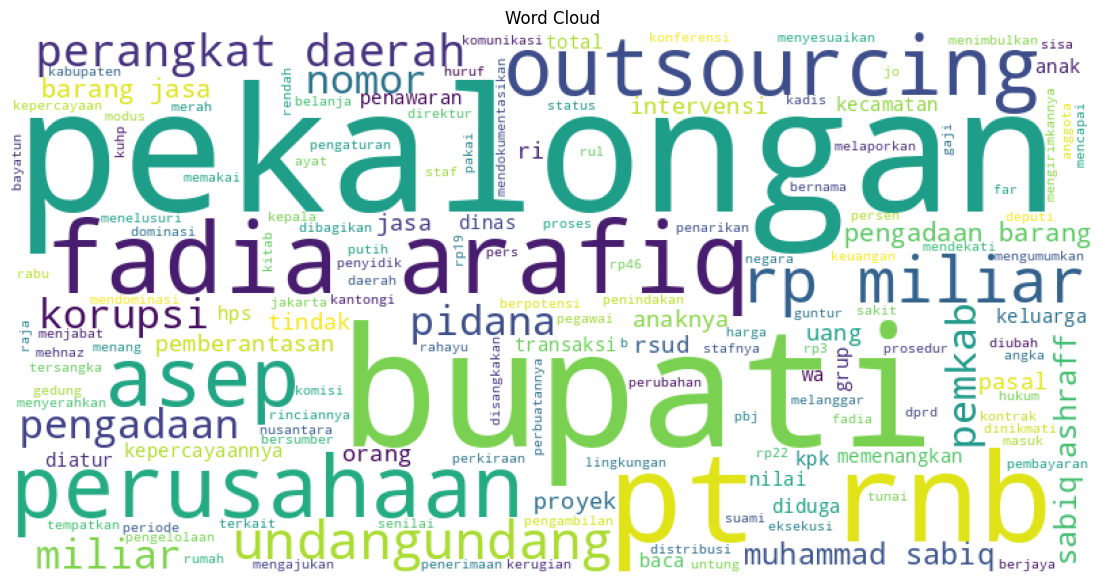

In [ ]:
#write word frequency analysis

#WordCloud

text_clean = " ". join(cleaned_article)

wordcloud = WordCloud(
    background_color="white",
    width=800,
    height=400,
).generate(text_clean)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud)
plt.title("Word Cloud")
plt.axis("off")
plt.show()

In [ ]:
#check the words that often appear


---
# Linguistic Processing #

---

# Part-of-Speech Tagging Menggunakan Stanza

Setelah tahap **text preprocessing** selesai dilakukan, langkah selanjutnya dalam pipeline **Natural Language Processing (NLP)** adalah melakukan **analisis linguistik**. Salah satu teknik yang umum digunakan adalah **Part-of-Speech (POS) Tagging**.

**Part-of-Speech Tagging** adalah proses memberikan label kelas kata pada setiap kata dalam kalimat. Label ini menunjukkan fungsi gramatikal suatu kata dalam struktur kalimat.

POS tagging memiliki berbagai manfaat dalam analisis NLP, antara lain:

1. Memahami struktur kalimat

2. Membantu proses dependency parsing

3. Membantu named entity recognition

4. Digunakan dalam information extraction

5. Digunakan dalam machine translation

Contoh kelas kata:

| Kelas Kata | Contoh |
|------------|--------|
| Noun (kata benda) | buku, rumah |
| Verb (kata kerja) | makan, berjalan |
| Adjective (kata sifat) | besar, cepat |
| Adverb (kata keterangan) | sangat, cepat |

Pada eksperimen ini digunakan library **Stanza**, yaitu library NLP yang dikembangkan oleh **Stanford NLP Group**.

---

# Library Stanza

**Stanza** merupakan toolkit NLP yang menyediakan berbagai fitur pemrosesan bahasa alami seperti:

- Tokenization
- Part-of-Speech Tagging
- Lemmatization
- Named Entity Recognition (NER)
- Dependency Parsing

Stanza mendukung berbagai bahasa termasuk **Bahasa Indonesia**.

---

# Mengunduh Model Bahasa Indonesia

```python
stanza.download("id")
```

### Universal POS Tag

Stanza menggunakan sistem **Universal POS Tags (UPOS)** untuk memberi label kelas kata pada setiap token dalam teks.

Berikut beberapa tag yang sering muncul:

| Tag  | Arti |
|------|------|
| NOUN | Kata benda |
| VERB | Kata kerja |
| PROPN | Proper noun (nama orang/tempat) |
| ADJ | Kata sifat |
| ADV | Kata keterangan |
| ADP | Preposisi |
| PRON | Kata ganti |

In [ ]:
# Do POS Tagging here
stanza.download("id")

nlp = stanza.Pipeline("id")

#ambil artikel awal
doc = nlp(article)

for sentence in doc.sentences:
    for word in sentence.words:
        print(word.text, word.upos)

INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor    | Package      |
-------------------------------
| tokenize     | gsd          |
| mwt          | gsd          |
| pos          | gsd_charlm   |
| lemma        | gsd_nocharlm |
| constituency | icon_charlm  |
| depparse     | gsd_charlm   |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: constituency
INFO:stanza:Loading: depparse
INFO:stanza:Done loading processors!


Bupati NOUN
Pekalongan PROPN
Fadia PROPN
Arafiq PROPN
dan CCONJ
Anak NOUN
nya PRON
Intervensi PROPN
Kadis PROPN
untuk ADP
Pakai PROPN
Jasa PROPN
Perusahaan PROPN
Mereka PRON
Tim PROPN
Redaksi PROPN
JAKARTA PROPN
, PUNCT
KOMPAS.com PROPN
- PUNCT
Komisi PROPN
Pemberantasan PROPN
Korupsi PROPN
( PUNCT
KPK PROPN
) PUNCT
mengatakan VERB
, PUNCT
Bupati NOUN
Pekalongan PROPN
Fadia PROPN
Arafiq PROPN
melalui VERB
anak NOUN
nya PRON
yang PRON
menjabat VERB
sebagai ADP
Anggota PROPN
DPRD PROPN
, PUNCT
Muhammad PROPN
Sabiq PROPN
Ashraff PROPN
, PUNCT
dan CCONJ
orang NOUN
kepercayaan NOUN
nya PRON
diduga ADV
melakukan VERB
intervensi NOUN
kepada ADP
sejumlah DET
Perangkat PROPN
Daerah PROPN
Pemkab PROPN
Pekalongan PROPN
agar SCONJ
memakai VERB
perusahaan NOUN
mereka PRON
yakni ADP
PT PROPN
RNB PROPN
( PUNCT
Raja PROPN
Nusantara PROPN
Berjaya PROPN
) PUNCT
untuk ADP
pengadaan NOUN
barang NOUN
dan CCONJ
jasa NOUN
outsourcing NOUN
. PUNCT
Hal NOUN
tersebut DET
disampaikan VERB
Deputi PROPN
Penindakan

# Named Entity Recognition (NER)

Setelah melakukan proses **Part-of-Speech Tagging**, langkah selanjutnya dalam pipeline **Natural Language Processing (NLP)** adalah melakukan **Named Entity Recognition (NER)**.

Named Entity Recognition adalah teknik dalam NLP yang digunakan untuk **mengidentifikasi dan mengklasifikasikan entitas penting dalam teks**.

Entitas yang biasanya dideteksi antara lain:

- Nama orang
- Nama organisasi
- Nama lokasi
- Tanggal
- Nilai uang
- Persentase

NER sangat penting dalam analisis teks karena membantu mengekstrak **informasi penting dari dokumen secara otomatis**.

---

## Manfaat Named Entity Recognition ##

Named Entity Recognition memiliki berbagai manfaat dalam analisis teks, antara lain:

1. Mengekstrak informasi penting dari dokumen

2. Mengidentifikasi tokoh dalam berita

3. Menemukan organisasi atau institusi yang terlibat

4. Menganalisis hubungan antar entitas

5. Digunakan dalam sistem information extraction

In [ ]:
!pip install spacy
!python -m spacy download xx_ent_wiki_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 62.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#Named Entity Recognition (NER)
import spacy

nlp = spacy.load("xx_ent_wiki_sm")
doc = nlp(article)

for ent in doc.ents:
    print(ent.text, ent.label_)

Pekalongan Fadia Arafiq PER
Anaknya Intervensi Kadis PER
Pakai Jasa Perusahaan PER
Tim Redaksi PER
KOMPAS.com - Komisi ORG
KPK ORG
Bupati Pekalongan Fadia Arafiq PER
Anggota DPRD PER
Muhammad Sabiq Ashraff PER
Daerah Pemkab Pekalongan PER
PT RNB ORG
Raja Nusantara Berjaya PER
Hal PER
Deputi Penindakan PER
Fadia Arafiq PER
Pemkab Pekalongan PER
FAR ORG
Fadia Arafiq PER
Muhammad Sabiq Ashraff PER
Kepala Dinas LOC
PT RNB ORG
sejumlah dinas PER
Rumah Sakit Umum Daerah PER
RSUD ORG
Kabupaten Pekalongan PER
Asep PER
Merah Putih PER
Jakarta LOC
Rabu LOC
Baca PER
Fadia Arafiq Tempatkan PER
Menang Proyek PER
Pekalongan Asep PER
yang mengajukan PER
yang rendah PER
PT RNB ORG
Sehingga PER
menimbulkan kerugian keuangan negara PER
daerah yang PER
Harga Perkiraan Sendiri PER
HPS ORG
PT RNB ORG
PT RNB ORG
HPS ORG
Hal PER
PT RNB ORG
PBJ ORG
Pemkab Pekalongan PER
Perangkat Daerah MISC
Baca PER
Dominasi Proyek Outsourcing PER
Keluarga Bupati PER
PT RNB ORG
Rp46 MISC
PT RNB ORG
Daerah di Pemkab Pekalonga

# Depedency parsing

# Dependency Parsing dalam NLP

## Pengertian

**Dependency Parsing** adalah teknik dalam **Natural Language Processing (NLP)** yang digunakan untuk menganalisis **hubungan tata bahasa antar kata dalam sebuah kalimat**.

Metode ini menentukan hubungan antara:

- **Head** : kata utama
- **Dependent** : kata yang bergantung pada head
- **Dependency Relation** : jenis hubungan antar kata

---

## Contoh

Kalimat:

The cat eats fish

struktur depedency"

     eats

    /    \

    cat    fish

    /



Hubungan:

| Kata | Head | Relasi |
|-----|-----|------|
| eats | ROOT | root |
| cat | eats | nsubj |
| fish | eats | obj |
| The | cat | det |

---

## Fungsi Dependency Parsing

Dependency parsing digunakan untuk:

- **Information Extraction**
- **Question Answering**
- **Machine Translation**
- **Sentiment Analysis**



In [ ]:
# Dependency parsing

nlp = spacy.load("en_core_web_sm")
doc = nlp(article)

for token in doc:
    print( token.head.text,"->", token.dep_,"->",token.text)

Fadia -> compound -> Bupati
Fadia -> compound -> Pekalongan
untuk -> compound -> Fadia
Intervensi -> compound -> Arafiq
Intervensi -> compound -> dan
Intervensi -> compound -> Anaknya
Kadis -> compound -> Intervensi
untuk -> compound -> Kadis
sebagai -> nsubj -> untuk
Jasa -> compound -> Pakai
Mereka -> compound -> Jasa
Mereka -> compound -> Perusahaan
untuk -> appos -> Mereka
Redaksi -> compound -> Tim
JAKARTA -> compound -> Redaksi
untuk -> appos -> JAKARTA
JAKARTA -> punct -> ,
Komisi -> compound -> KOMPAS.com
Komisi -> punct -> -
Korupsi -> compound -> Komisi
Korupsi -> compound -> Pemberantasan
mengatakan -> nmod -> Korupsi
Korupsi -> punct -> (
mengatakan -> nmod -> KPK
mengatakan -> punct -> )
JAKARTA -> appos -> mengatakan
JAKARTA -> punct -> ,
menjabat -> compound -> Bupati
Fadia -> compound -> Pekalongan
menjabat -> compound -> Fadia
menjabat -> compound -> Arafiq
menjabat -> compound -> melalui
menjabat -> compound -> anaknya
menjabat -> compound -> yang
JAKARTA -> appos -> 

# Knowledge Graph Entity

# Knowledge Graph

## Pengertian

**Knowledge Graph** adalah representasi pengetahuan dalam bentuk **graf** yang menunjukkan hubungan antar entitas.

Knowledge graph terdiri dari tiga komponen utama:

- **Entity (Node)** → objek atau konsep
- **Relation (Edge)** → hubungan antar entitas
- **Triple** → struktur pengetahuan *(Subject – Predicate – Object)*

---

## Contoh Knowledge Graph

Kalimat:

Barack Obama was born in Hawaii

Triple yang dihasilkan:

(Barack Obama) — born_in — (Hawaii)

Struktur graf:

Barack Obama → born_in → Hawaii

## Proses Pembuatan Knowledge Graph dalam NLP

1. Text Collection  
2. Named Entity Recognition (NER)  
3. Dependency Parsing  
4. Relation Extraction  
5. Graph Construction  

---

## Kegunaan Knowledge Graph

Knowledge graph digunakan untuk:

- **Search Engine** (Google Knowledge Graph)
- **Question Answering System**
- **Recommendation System**
- **Semantic Search**

---

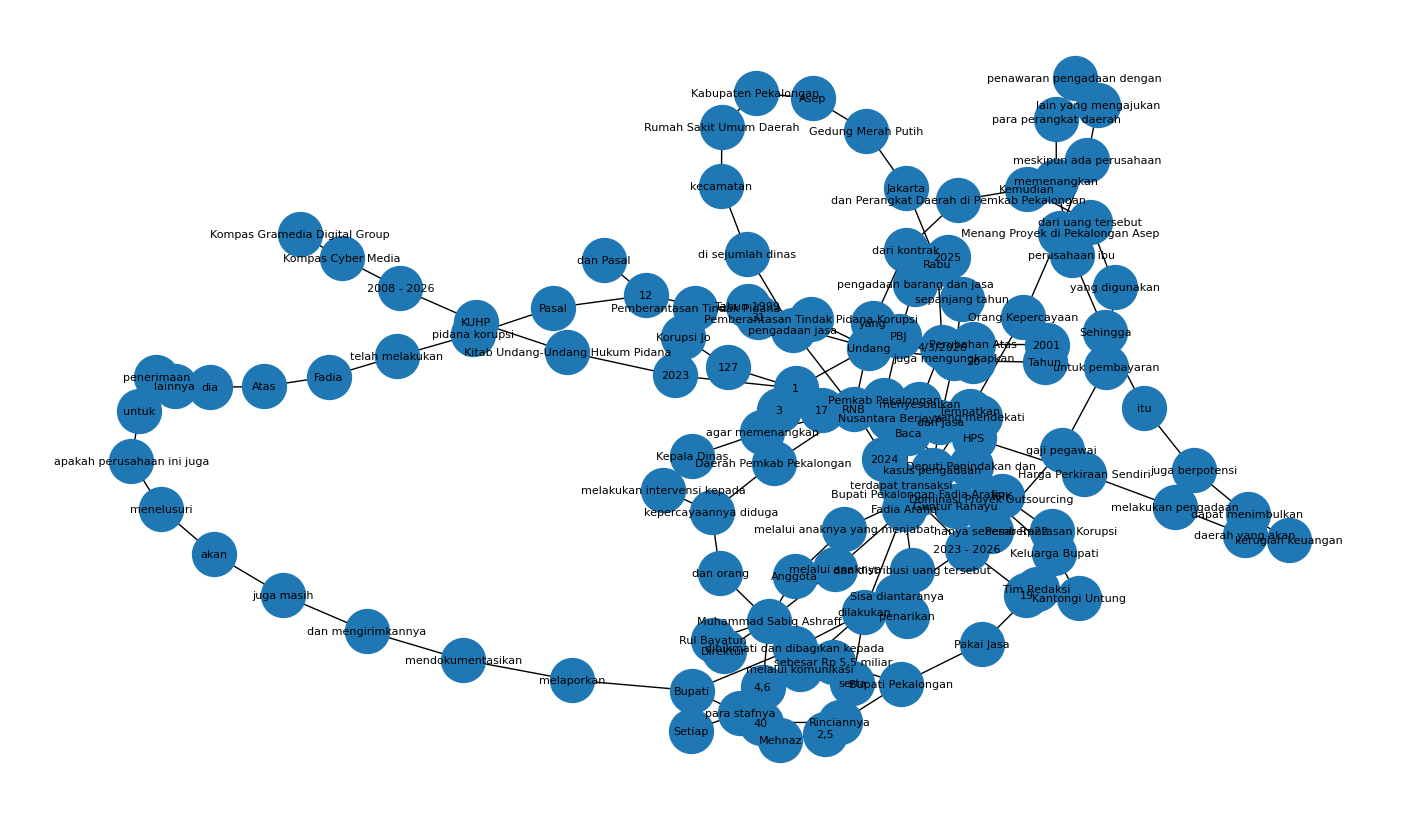

In [ ]:
# Knowledge Graph Entity

G = nx.Graph()

entities = [ent.text for ent in doc.ents]

for ent in entities:
    G.add_node(ent)

for i in range(len(entities) -1):
    G.add_edge(entities[i], entities[i+1])

plt.figure(figsize=(14, 8))

nx.draw(G,
        with_labels=True,
        node_size = 1000,
        font_size = 8)

plt.show()